# Trabalho Computacional 2 - Perceptron Multicamada no Problema MNIST

### Autores

- **Pedro Araujo Cordeiro Viana** — Matrícula: **202067452**
- **Maria Fernanda Tôrres Rocha** — Matrícula: **221021527**

---

## 1. Introdução e Preparação

Neste trabalho, implementamos o **Perceptron Multicamada (MLP)** para classificar dígitos manuscritos do dataset MNIST.
O MNIST contém 70.000 imagens de dígitos (0–9) em tons de cinza, com resolução 28×28 pixels:
- 60.000 imagens de **treinamento**
- 10.000 imagens de **validação**

Cada imagem é achatada em um vetor de 784 valores (28×28), que serve como entrada para a rede neural.
A saída é uma das 10 classes (dígitos 0 a 9).

In [1]:
# descomente se precisar instalar as dependências
#!pip install d2l seaborn torch torchvision scikit-learn

In [2]:
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    balanced_accuracy_score,
)
import seaborn as sns
from IPython import display as ipydisplay

torch.manual_seed(42)

### 1.1 Carregando o Dataset MNIST

O MNIST está disponível diretamente no PyTorch via `torchvision.datasets.MNIST`.

In [3]:
class MNISTData(d2l.DataModule):
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([
            transforms.Resize(resize),
            transforms.ToTensor()
        ])
        self.train = torchvision.datasets.MNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.MNIST(
            root=self.root, train=False, transform=trans, download=True)

    def text_labels(self, indices):
        return [str(int(i)) for i in indices]


@d2l.add_to_class(MNISTData)
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(
        data, self.batch_size, shuffle=train, num_workers=0
    )


data = MNISTData(batch_size=64)
print(f'Treinamento: {len(data.train)} amostras')
print(f'Validação:   {len(data.val)} amostras')
print(f'Shape:       {data.train.data.shape}')

X, y = next(iter(data.train_dataloader()))
print(f'Batch X: {X.shape} ({X.dtype})')
print(f'Batch y: {y.shape} ({y.dtype})')

Treinamento: 60000 amostras
Validação:   10000 amostras
Shape:       torch.Size([60000, 28, 28])
Batch X: torch.Size([64, 1, 28, 28]) (torch.float32)
Batch y: torch.Size([64]) (torch.int64)


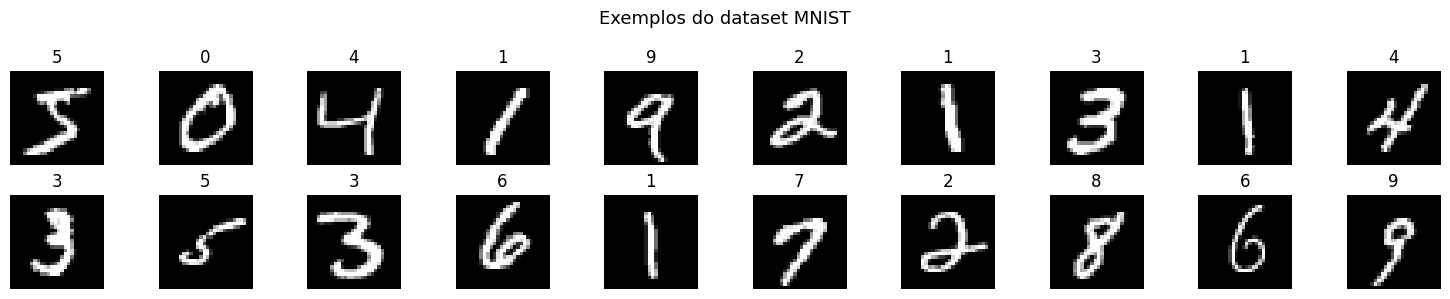

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    img, label = data.train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')
plt.suptitle('Exemplos do dataset MNIST', fontsize=13)
plt.tight_layout()
plt.show()

### 1.2 Funções Auxiliares

In [5]:
def eval_acc(model, loader):
    model.eval()
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in loader:
            metric.add(d2l.accuracy(model(X), y), y.numel())
    model.train()
    return metric[0] / metric[1]


def eval_metrics(model, loader):
    model.eval()
    all_y, all_preds = [], []
    with torch.no_grad():
        for X, y in loader:
            preds = torch.argmax(model(X), dim=1)
            all_y.append(y.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)
    metrics = {
        'acc': accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    model.train()
    return metrics


def summarize_metrics(metrics_list, keys):
    means = {k: float(np.mean([m[k] for m in metrics_list])) for k in keys}
    stds = {k: float(np.std([m[k] for m in metrics_list])) for k in keys}
    return means, stds


def print_metrics_summary(metrics_list, title='Metricas (media ± desvio)'):
    keys = ['acc', 'balanced_acc', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted']
    means, stds = summarize_metrics(metrics_list, keys)
    if title:
        print(title)
    for k in keys:
        print(f'  {k}: {means[k]:.4f} ± {stds[k]:.4f}')


def train_and_eval(model, dataset, max_epochs=10, label=''):
    trainer = d2l.Trainer(max_epochs=max_epochs)
    trainer.fit(model, dataset)
    metrics = eval_metrics(model, dataset.val_dataloader())
    acc = metrics['acc']
    # captura a figura do d2l antes do proximo clear_output apagar
    fig = model.board.fig
    fig.axes[0].set_title(f'{label} | Acuracia: {acc:.4f} ({acc*100:.2f}%)', fontsize=10)
    return metrics, fig

---

## 2. Modelos e Arquiteturas

Seguimos a progressão histórica das técnicas de treinamento de MLPs:
da sigmoide + SGD dos anos 80/90 até arquiteturas modernas com ReLU e Adam.

Em todos os modelos:
- A primeira camada é `nn.Flatten()`, que transforma a imagem 28×28 em vetor de 784 valores
- A camada de saída é **linear** (sem softmax explícito), pois o PyTorch aplica o softmax
  internamente na função de custo `CrossEntropyLoss`

Para cada variação, realizamos 3 rodadas de treinamento com sementes aleatórias diferentes, calculando média e desvio padrão de diversas métricas de desempenho (acurácia, F1-macro, precisão-macro, recall-macro e acurácia balanceada).

### 2a) Perceptron com uma camada escondida, Sigmoid e SGD

**Arquitetura:** Flatten → Linear(128) → Sigmoid → Linear(10)

A **função sigmoide** $\sigma(x) = 1/(1+e^{-x})$ foi a ativação padrão nas primeiras redes neurais.
Ela mapeia qualquer valor para o intervalo $(0,1)$, imitando o "disparo" de um neurônio biológico.

O otimizador **SGD** (Descida de Gradiente Estocástica) atualiza os pesos seguindo o gradiente
do erro com uma taxa de aprendizado fixa, simples mas sem adaptação automática.

Um problema clássico da sigmoide é o **gradiente evanescente**: nas regiões de saturação
(valores muito altos ou baixos), a derivada é quase zero, dificultando o aprendizado
em redes mais profundas.

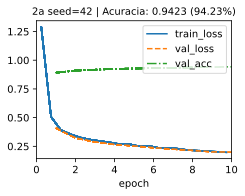

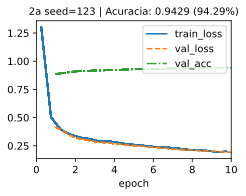

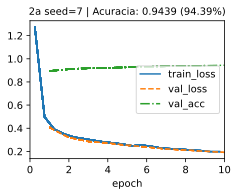

Media ACC: 0.9430 ± 0.0007
Metricas (media ± desvio)
  acc: 0.9430 ± 0.0007
  balanced_acc: 0.9420 ± 0.0007
  precision_macro: 0.9430 ± 0.0005
  recall_macro: 0.9420 ± 0.0007
  f1_macro: 0.9422 ± 0.0007
  f1_weighted: 0.9429 ± 0.0007


In [6]:
class SigmoidSGD(d2l.Classifier):
    """1 camada oculta (128), ativacao Sigmoid, otimizador SGD."""
    def __init__(self, num_outputs=10, num_hidden=128, lr=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.CrossEntropyLoss()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hidden),
            nn.Sigmoid(),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)


print('=== 2a) Sigmoid + SGD ===')
accs_2a, metrics_2a, models_2a, figs_2a = [], [], [], []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = SigmoidSGD(lr=0.1)
    metrics, fig = train_and_eval(m, data, max_epochs=10, label=f'2a seed={seed}')
    accs_2a.append(metrics['acc'])
    metrics_2a.append(metrics)
    models_2a.append((m, metrics['acc']))
    figs_2a.append(fig)

# exibe os 3 graficos juntos apos o treinamento
ipydisplay.clear_output(wait=True)
for fig in figs_2a:
    ipydisplay.display(fig)
    plt.close(fig)

print(f'Media ACC: {np.mean(accs_2a):.4f} ± {np.std(accs_2a):.4f}')
print_metrics_summary(metrics_2a)

### 2b) Otimizador Adam

**Arquitetura:** Flatten → Linear(128) → Sigmoid → Linear(10) — mesmo do 2a

O **Adam** ("Estimativa Adaptativa de Momentos") resolve o principal
inconveniente do SGD: a dificuldade de escolher uma boa taxa de aprendizado.

Ele mantém médias ponderadas do gradiente (1º momento, $m$) e do gradiente ao quadrado
(2º momento, $v$), adaptando a taxa de aprendizado por parâmetro:

$$\theta \leftarrow \theta - \alpha \cdot \hat{m} / (\sqrt{\hat{v}} + \varepsilon)$$

Isso faz com que parâmetros com gradientes grandes deem passos menores e vice-versa,
acelerando a convergência e tornando o treinamento mais estável.

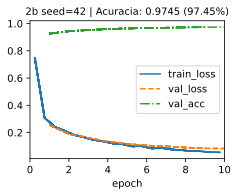

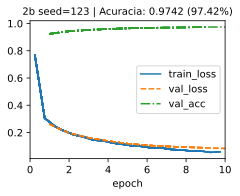

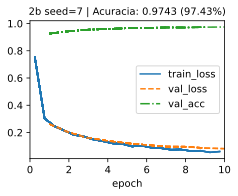

Media ACC: 0.9743 ± 0.0001
Metricas (media ± desvio)
  acc: 0.9743 ± 0.0001
  balanced_acc: 0.9740 ± 0.0002
  precision_macro: 0.9743 ± 0.0001
  recall_macro: 0.9740 ± 0.0002
  f1_macro: 0.9741 ± 0.0001
  f1_weighted: 0.9743 ± 0.0001


In [7]:
class SigmoidAdam(d2l.Classifier):
    """1 camada oculta (128), ativacao Sigmoid, otimizador Adam."""
    def __init__(self, num_outputs=10, num_hidden=128, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.CrossEntropyLoss()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hidden),
            nn.Sigmoid(),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


print('=== 2b) Sigmoid + Adam ===')
accs_2b, metrics_2b, models_2b, figs_2b = [], [], [], []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = SigmoidAdam(lr=0.001)
    metrics, fig = train_and_eval(m, data, max_epochs=10, label=f'2b seed={seed}')
    accs_2b.append(metrics['acc'])
    metrics_2b.append(metrics)
    models_2b.append((m, metrics['acc']))
    figs_2b.append(fig)

ipydisplay.clear_output(wait=True)
for fig in figs_2b:
    ipydisplay.display(fig)
    plt.close(fig)

print(f'Media ACC: {np.mean(accs_2b):.4f} ± {np.std(accs_2b):.4f}')
print_metrics_summary(metrics_2b)

### 2c) A função ReLU

**Arquitetura:** Flatten → Linear(128) → ReLU → Linear(10)

A **ReLU** (Rectified Linear Unit) é definida como: $\text{ReLU}(x) = \max(0, x)$.

Apesar de ser uma função extremamente simples, ela trouxe vantagens:

- **Sem gradiente evanescente** para $x > 0$: a derivada é exatamente 1, permitindo que os
  gradientes fluam livremente pelas camadas durante o backpropagation
- **Esparsidade**: neurônios com ativação negativa retornam zero, tornando a rede mais eficiente
- **Computacionalmente barata**: apenas uma comparação com zero

A única desvantagem é o "neurônio morto" (dead ReLU): se a pré-ativação for sempre negativa,
o gradiente é zero e o neurônio para de aprender.

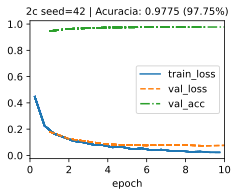

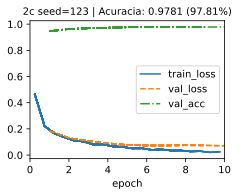

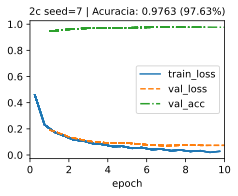

Media ACC: 0.9773 ± 0.0007
Metricas (media ± desvio)
  acc: 0.9773 ± 0.0007
  balanced_acc: 0.9771 ± 0.0006
  precision_macro: 0.9774 ± 0.0009
  recall_macro: 0.9771 ± 0.0006
  f1_macro: 0.9771 ± 0.0007
  f1_weighted: 0.9773 ± 0.0007


In [8]:
class ReLUAdam(d2l.Classifier):
    """1 camada oculta (128), ativacao ReLU, otimizador Adam."""
    def __init__(self, num_outputs=10, num_hidden=128, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.CrossEntropyLoss()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hidden),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


print('=== 2c) ReLU + Adam ===')
accs_2c, metrics_2c, models_2c, figs_2c = [], [], [], []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = ReLUAdam(lr=0.001)
    metrics, fig = train_and_eval(m, data, max_epochs=10, label=f'2c seed={seed}')
    accs_2c.append(metrics['acc'])
    metrics_2c.append(metrics)
    models_2c.append((m, metrics['acc']))
    figs_2c.append(fig)

ipydisplay.clear_output(wait=True)
for fig in figs_2c:
    ipydisplay.display(fig)
    plt.close(fig)

print(f'Media ACC: {np.mean(accs_2c):.4f} ± {np.std(accs_2c):.4f}')
print_metrics_summary(metrics_2c)

### 2d) Redes Maiores

Com a melhoria geral na capacidade computacional e o sucesso do ReLU + Adam, tornou-se
viável treinar redes maiores. Testamos duas variações:

**2d.1** — Uma camada oculta com **256 neurônios** (dobro do anterior)
- Rede mais **larga**: mais neurônios por camada aumentam a capacidade de representação

**2d.2** — Duas camadas ocultas: **256 → 128 neurônios**
- Rede mais **profunda**: camadas adicionais permitem aprender representações hierárquicas,
  onde conceitos simples (bordas, curvas) nas primeiras camadas compõem conceitos mais
  complexos nas camadas seguintes

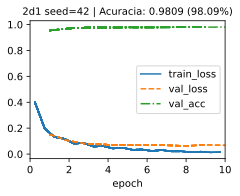

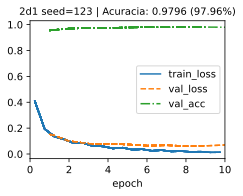

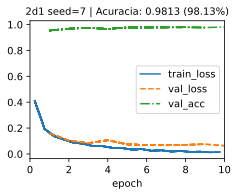

Media ACC: 0.9806 ± 0.0007
Metricas (media ± desvio)
  acc: 0.9806 ± 0.0007
  balanced_acc: 0.9804 ± 0.0007
  precision_macro: 0.9806 ± 0.0008
  recall_macro: 0.9804 ± 0.0007
  f1_macro: 0.9805 ± 0.0007
  f1_weighted: 0.9806 ± 0.0007


In [9]:
class ReLUAdam256(d2l.Classifier):
    """1 camada oculta (256), ativacao ReLU, otimizador Adam."""
    def __init__(self, num_outputs=10, num_hidden=256, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.CrossEntropyLoss()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hidden),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


print('=== 2d.1) ReLU + Adam + 256 neuronios ===')
accs_2d1, metrics_2d1, models_2d1, figs_2d1 = [], [], [], []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = ReLUAdam256(lr=0.001)
    metrics, fig = train_and_eval(m, data, max_epochs=10, label=f'2d1 seed={seed}')
    accs_2d1.append(metrics['acc'])
    metrics_2d1.append(metrics)
    models_2d1.append((m, metrics['acc']))
    figs_2d1.append(fig)

ipydisplay.clear_output(wait=True)
for fig in figs_2d1:
    ipydisplay.display(fig)
    plt.close(fig)

print(f'Media ACC: {np.mean(accs_2d1):.4f} ± {np.std(accs_2d1):.4f}')
print_metrics_summary(metrics_2d1)

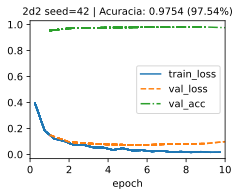

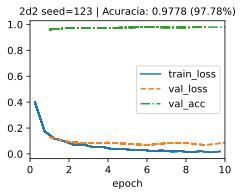

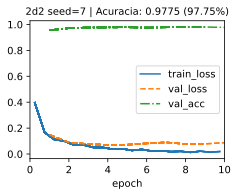

Media ACC: 0.9769 ± 0.0011
Metricas (media ± desvio)
  acc: 0.9769 ± 0.0011
  balanced_acc: 0.9768 ± 0.0012
  precision_macro: 0.9768 ± 0.0008
  recall_macro: 0.9768 ± 0.0012
  f1_macro: 0.9767 ± 0.0010
  f1_weighted: 0.9769 ± 0.0011


In [10]:
class ReLUAdam2Layer(d2l.Classifier):
    """2 camadas ocultas (256 -> 128), ativacao ReLU, otimizador Adam."""
    def __init__(self, num_outputs=10, h1=256, h2=128, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.loss = nn.CrossEntropyLoss()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(h1),
            nn.ReLU(),
            nn.LazyLinear(h2),
            nn.ReLU(),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


print('=== 2d.2) 2 camadas ocultas (256->128) + ReLU + Adam ===')
accs_2d2, metrics_2d2, models_2d2, figs_2d2 = [], [], [], []
for seed in [42, 123, 7]:
    torch.manual_seed(seed)
    m = ReLUAdam2Layer(lr=0.001)
    metrics, fig = train_and_eval(m, data, max_epochs=10, label=f'2d2 seed={seed}')
    accs_2d2.append(metrics['acc'])
    metrics_2d2.append(metrics)
    models_2d2.append((m, metrics['acc']))
    figs_2d2.append(fig)

ipydisplay.clear_output(wait=True)
for fig in figs_2d2:
    ipydisplay.display(fig)
    plt.close(fig)

print(f'Media ACC: {np.mean(accs_2d2):.4f} ± {np.std(accs_2d2):.4f}')
print_metrics_summary(metrics_2d2)

### Resumo Comparativo

Modelo                                       ACC       F1-mac     Prec-mac   Recall-mac         BACC
2a) Sigmoid + SGD (128)             0.9430±0.0007 0.9422±0.0007 0.9430±0.0005 0.9420±0.0007 0.9420±0.0007
2b) Sigmoid + Adam (128)            0.9743±0.0001 0.9741±0.0001 0.9743±0.0001 0.9740±0.0002 0.9740±0.0002
2c) ReLU + Adam (128)               0.9773±0.0007 0.9771±0.0007 0.9774±0.0009 0.9771±0.0006 0.9771±0.0006
2d.1) ReLU + Adam (256)             0.9806±0.0007 0.9805±0.0007 0.9806±0.0008 0.9804±0.0007 0.9804±0.0007
2d.2) ReLU + Adam (256->128)        0.9769±0.0011 0.9767±0.0010 0.9768±0.0008 0.9768±0.0012 0.9768±0.0012


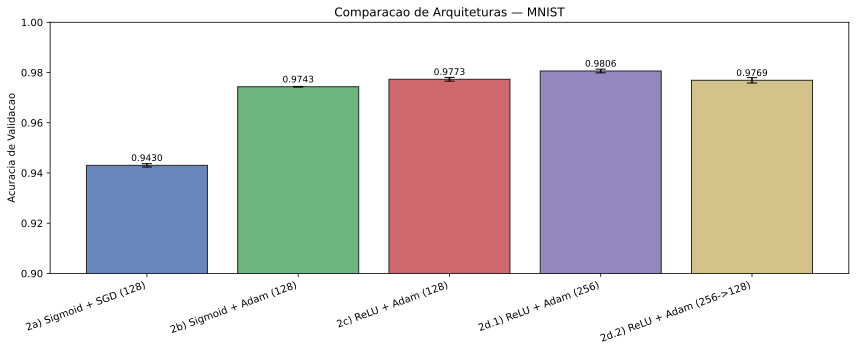


Melhor configuracao: 2d.1) ReLU + Adam (256) | ACC 0.9806±0.0007 | F1-mac 0.9805±0.0007


In [11]:
configs = [
    ('2a) Sigmoid + SGD (128)',      accs_2a,  models_2a,  metrics_2a),
    ('2b) Sigmoid + Adam (128)',     accs_2b,  models_2b,  metrics_2b),
    ('2c) ReLU + Adam (128)',        accs_2c,  models_2c,  metrics_2c),
    ('2d.1) ReLU + Adam (256)',      accs_2d1, models_2d1, metrics_2d1),
    ('2d.2) ReLU + Adam (256->128)', accs_2d2, models_2d2, metrics_2d2),
]

metric_keys = ['acc', 'f1_macro', 'precision_macro', 'recall_macro', 'balanced_acc']
metric_labels = {
    'acc': 'ACC',
    'f1_macro': 'F1-mac',
    'precision_macro': 'Prec-mac',
    'recall_macro': 'Recall-mac',
    'balanced_acc': 'BACC',
}


def fmt_metric(mean, std):
    return f'{mean:.4f}±{std:.4f}'


# tabela de resultados
print('=' * 110)
header = f'{"Modelo":<35} ' + ' '.join([f'{metric_labels[k]:>12}' for k in metric_keys])
print(header)
print('=' * 110)
for name, res, _, metrics_list in configs:
    means, stds = summarize_metrics(metrics_list, metric_keys)
    row = f'{name:<35} ' + ' '.join(
        [f'{fmt_metric(means[k], stds[k]):>12}' for k in metric_keys]
    )
    print(row)
print('=' * 110)

names  = [c[0] for c in configs]
means  = [np.mean(c[1]) for c in configs]
stds   = [np.std(c[1])  for c in configs]

# grafico de barras com barra de erro
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(range(len(names)), means, yerr=stds, capsize=5,
              color=colors, alpha=0.85, edgecolor='black')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('Acuracia de Validacao')
ax.set_title('Comparacao de Arquiteturas — MNIST')
ax.set_ylim(0.9, 1.0)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{m:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# seleciona o melhor modelo automaticamente
best_idx   = int(np.argmax(means))
best_name  = names[best_idx]
best_model = max(configs[best_idx][2], key=lambda x: x[1])[0]

best_means, best_stds = summarize_metrics(configs[best_idx][3], metric_keys)
print(
    f'\nMelhor configuracao: {best_name} | '
    f'ACC {best_means["acc"]:.4f}±{best_stds["acc"]:.4f} | '
    f'F1-mac {best_means["f1_macro"]:.4f}±{best_stds["f1_macro"]:.4f}'
)

---

## 3. Visualização de Erros de Classificação

Usando a melhor rodada do melhor modelo obtido (ReLU + Adam - 256 neurônios), percorremos **todos os minibatches** do conjunto de validação usando o iterador `dataset.val_dataloader()` e acumulamos os exemplos classificados incorretamente.

Esta abordagem é necessária porque o MLP tem alta acurácia: pode não haver nenhum erro
em um determinado minibatch. Iterar por todos garante que encontremos os erros existentes.
Além disso, usar o iterador é a forma correta para datasets grandes, pois não exige
carregar tudo em memória de uma só vez.

In [12]:
best_model.eval()
err_X, err_y_true, err_y_pred = [], [], []

with torch.no_grad():
    for X_batch, y_batch in data.val_dataloader():
        preds = torch.argmax(best_model(X_batch), dim=1)
        mask  = (preds != y_batch)
        if mask.any():
            err_X.append(X_batch[mask])
            err_y_true.append(y_batch[mask])
            err_y_pred.append(preds[mask])

err_X = torch.cat(err_X)
err_y_true = torch.cat(err_y_true)
err_y_pred = torch.cat(err_y_pred)

print(f'Total de erros: {len(err_X)} de {len(data.val)} imagens')
print(f'Acurácia: {1 - len(err_X)/len(data.val):.4f}')

Total de erros: 187 de 10000 imagens
Acurácia: 0.9813


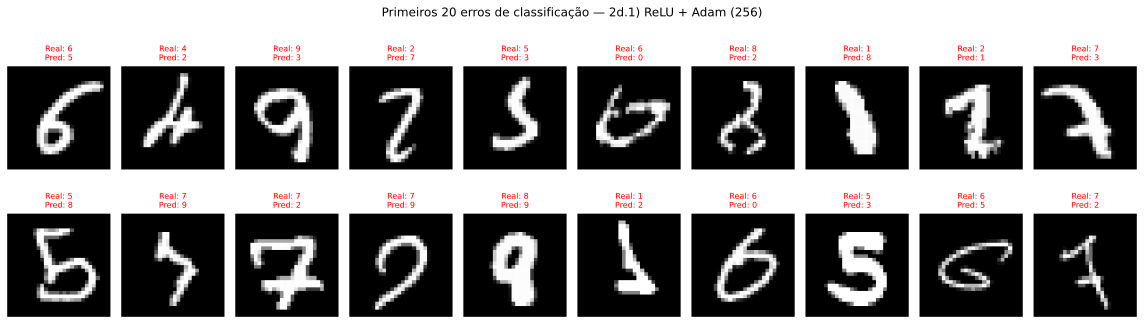

In [13]:
n_show = min(20, len(err_X))
ncols  = min(10, n_show)
nrows  = (n_show + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.6, nrows * 2.5))
axes = np.array(axes).flatten()

for i in range(n_show):
    axes[i].imshow(err_X[i].squeeze(), cmap='gray')
    axes[i].set_title(
        f'Real: {err_y_true[i].item()}\nPred: {err_y_pred[i].item()}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Primeiros {n_show} erros de classificação — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

### Discussão: Um humano cometeria esses erros?

Sim, em grande parte seria razoável que um humano cometesse erros semelhantes.
Os dígitos mal classificados pelo modelo costumam ser aqueles escritos de forma ambígua,
com traços que se assemelham visualmente a outro dígito.

Exemplos típicos de confusões "humanas":
- Um **4** com o topo fechado pode parecer um **9**
- Um **7** escrito com traço quase vertical se assemelha a um **1**
- Um **3** com a curva inferior incompleta pode ser confundido com um **5**
- Um **8** mal formado pode parecer um **3** ou **0**

Isso sugere que os erros do modelo não são "aleatórios". Ele está capturando
características visuais relevantes, mas encontra dificuldade justamente nas mesmas
ambiguidades que um humano também encontraria.

---

## 4. Matriz de Confusão

A matriz de confusão é uma tabela 10×10 onde:
- Cada **linha** representa a classe **verdadeira** (dígito real)
- Cada **coluna** representa a classe **predita** (o que a rede achou)
- Os valores na **diagonal principal** são os **acertos**
- Os valores **fora da diagonal** são os **erros**: a célula (i, j) indica quantas vezes
  o dígito i foi classificado como j

Acumulamos todas as predições percorrendo os minibatches via `dataset.val_dataloader()`
e então chamamos `confusion_matrix` do scikit-learn de uma só vez.

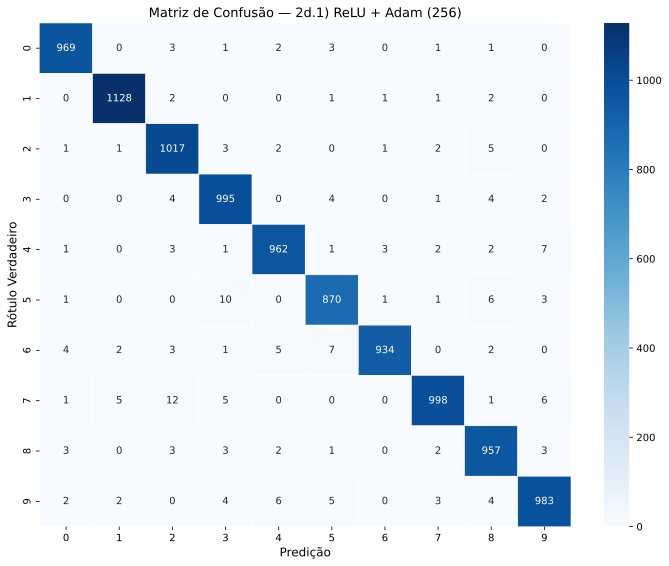

In [14]:
best_model.eval()
all_y, all_preds = [], []

with torch.no_grad():
    for X_batch, y_batch in data.val_dataloader():
        preds = torch.argmax(best_model(X_batch), dim=1)
        all_y.extend(y_batch.numpy())
        all_preds.extend(preds.numpy())

cm = confusion_matrix(all_y, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predição', fontsize=12)
ax.set_ylabel('Rótulo Verdadeiro', fontsize=12)
ax.set_title(f'Matriz de Confusão — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
print('Confusão mais comum por classe:')
print('=' * 50)
print(f'{"Classe":^8} {"Confundida com":^15} {"Erros":^10} {"Total":^8}')
print('=' * 50)

for i in range(10):
    row   = cm[i].copy()
    total = row.sum()
    row[i] = 0
    if row.sum() > 0:
        j = row.argmax()
        print(f'{i:^8} {j:^15} {row[j]:^10} {total:^8}')
    else:
        print(f'{i:^8} {"(nenhum)":^15} {0:^10} {total:^8}')
print('=' * 50)

Confusão mais comum por classe:
 Classe  Confundida com    Erros     Total  
   0            2            3        980   
   1            2            2        1135  
   2            8            5        1032  
   3            2            4        1010  
   4            9            7        982   
   5            3            10       892   
   6            5            7        958   
   7            2            12       1028  
   8            0            3        974   
   9            4            6        1009  


### Discussão: As confusões fazem sentido?

Sim, as confusões mais comuns são altamente coerentes com a similaridade visual entre os dígitos:

- **4 → 9**: O dígito 4 com o topo fechado forma um formato similar ao 9
- **7 → 2**: Um 7 com a base estendida ou levemente curvada pode lembrar o traço diagonal e a base do 2
- **3 → 2, 5 e 8**: Todos esses três dígitos apresentam curvas e laços que podem lembrar o 3
- **5 → 3**: As curvas abertas desses dígitos são visualmente próximas
- **8 → 3** ou **8 → 0**: Um 8 mal formado pode perder a alça superior ou inferior
- **2 → 8**: Dependendo da escrita, o traço inferior do 2 pode remeter ao 8

Nenhuma confusão "impossível" aparece com frequência (ex: 1 ser classificado como 8),
o que indica que o modelo está aprendendo corretamente as estruturas visuais dos dígitos.
As confusões que ocorrem são exatamente as mesmas que um humano poderia cometer ao ler
uma caligrafia ruim, o que é um sinal de que o modelo está generalizando bem.

---

## 5. Conclusões

Acompanhamos a evolução histórica das técnicas de treinamento de MLPs aplicadas ao MNIST:

| Configuração | Inovação | Acurácia |
|---|---|---|
| 2a) Sigmoid + SGD | Baseline histórico | 0.9430 ± 0.0007 |
| 2b) Sigmoid + Adam | Otimizador adaptativo | 0.9743 ± 0.0001 |
| 2c) ReLU + Adam | Ativação moderna | 0.9773 ± 0.0007 |
| 2d.1) ReLU + Adam 256 | Rede mais larga | **0.9806 ± 0.0007** |
| 2d.2) ReLU + Adam 256→128 | Rede mais profunda | 0.9769 ± 0.0011 |

**Observações:**
- A troca do SGD pelo Adam (2a→2b) melhora a convergência mesmo mantendo a mesma arquitetura
- A ReLU (2c) resolve o problema do gradiente evanescente da sigmoide, melhorando o desempenho
- Redes maiores (2d) trazem ganho marginal no MNIST: o 2d.1 supera levemente o 2c (0.9806 vs 0.9773), com desvios padrão iguais (±0.0007), sugerindo que a melhoria é consistente mas pequena
- O desvio padrão entre rodadas permite avaliar a significância das diferenças: mudanças grandes como 2a→2b (diferença de ~0.031) são claramente significativas, enquanto diferenças pequenas como 2c vs 2d.2 (0.0004 de diferença com desvios de ±0.0007 e ±0.0011) se sobrepõem nos intervalos e provavelmente não são significativas